# Notebook 02 — Anomaly Detection

**Goal:** Detect anomalous records in the cleaned structured data using two approaches:
1. **Isolation Forest** — traditional ML, fast and interpretable
2. **Autoencoder** — deep learning, detects complex anomalies via reconstruction error

**Input:** `platform/outputs/cleaned_records.csv`

**Output:** `platform/outputs/anomaly_results.csv`

## 1. Imports & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths OK")
print(f"PyTorch version : {torch.__version__}")

Paths OK
PyTorch version : 2.11.0+cpu


## 2. Load Cleaned Data

In [2]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "cleaned_records.csv"))

print(f"Loaded : {df.shape}")
print()
df.head(3)

Loaded : (55492, 21)



,patient_id,match_type,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,...,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,length_of_stay,gender_conflict,age_conflict,has_conflict
0,1d751b54-8ff3-4fe6-91df-751a230c94d7,gender_age_match,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,...,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,False,False,False
1,90a958eb-68a4-aa61-85e0-e9f20b083d94,gender_age_match,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,...,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,False,False,False
2,07fc8824-40ff-4c97-898d-f906bc6f2fd3,gender_age_match,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,...,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,False,False,False


## 3. Feature Engineering

In [3]:
# Select features for anomaly detection
# Mix of numerical and encoded categorical features

features_df = df[[
    "Age",
    "Billing Amount",
    "Room Number",
    "length_of_stay",
    "Gender",
    "Blood Type",
    "Medical Condition",
    "Admission Type",
    "Test Results",
    "Medication"
]].copy()

# Encode categorical columns
cat_cols = ["Gender", "Blood Type", "Medical Condition",
            "Admission Type", "Test Results", "Medication"]

le = LabelEncoder()
for col in cat_cols:
    features_df[col] = le.fit_transform(features_df[col].astype(str))

print("Feature matrix shape:", features_df.shape)
print()
print("Features used:")
print(features_df.columns.tolist())

Feature matrix shape: (55492, 10)

Features used:
['Age', 'Billing Amount', 'Room Number', 'length_of_stay', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Test Results', 'Medication']


## 4. Scale Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

print(f"Scaled feature matrix : {X_scaled.shape}")
print(f"Mean  : {X_scaled.mean(axis=0).round(4)}")
print(f"Std   : {X_scaled.std(axis=0).round(4)}")

Scaled feature matrix : (55492, 10)
Mean  : [ 0. -0. -0. -0. -0. -0.  0.  0.  0.  0.]
Std   : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Method 1 — Isolation Forest

In [5]:
print("Running Isolation Forest...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # assume 5% anomaly rate
    random_state=42,
    n_jobs=-1
)

iso_predictions = iso_forest.fit_predict(X_scaled)
iso_scores      = iso_forest.decision_function(X_scaled)

# Convert: -1 = anomaly, 1 = normal → True/False
df["iso_anomaly"] = iso_predictions == -1
df["iso_score"]   = iso_scores

print("Done.")
print()
print("Isolation Forest Results:")
print(f"  Normal records  : {(~df['iso_anomaly']).sum()}")
print(f"  Anomaly records : {df['iso_anomaly'].sum()}")
print(f"  Anomaly rate    : {df['iso_anomaly'].mean()*100:.2f}%")

Running Isolation Forest...
Done.

Isolation Forest Results:
  Normal records  : 52717
  Anomaly records : 2775
  Anomaly rate    : 5.00%


## 6. Isolation Forest — Visualize Results

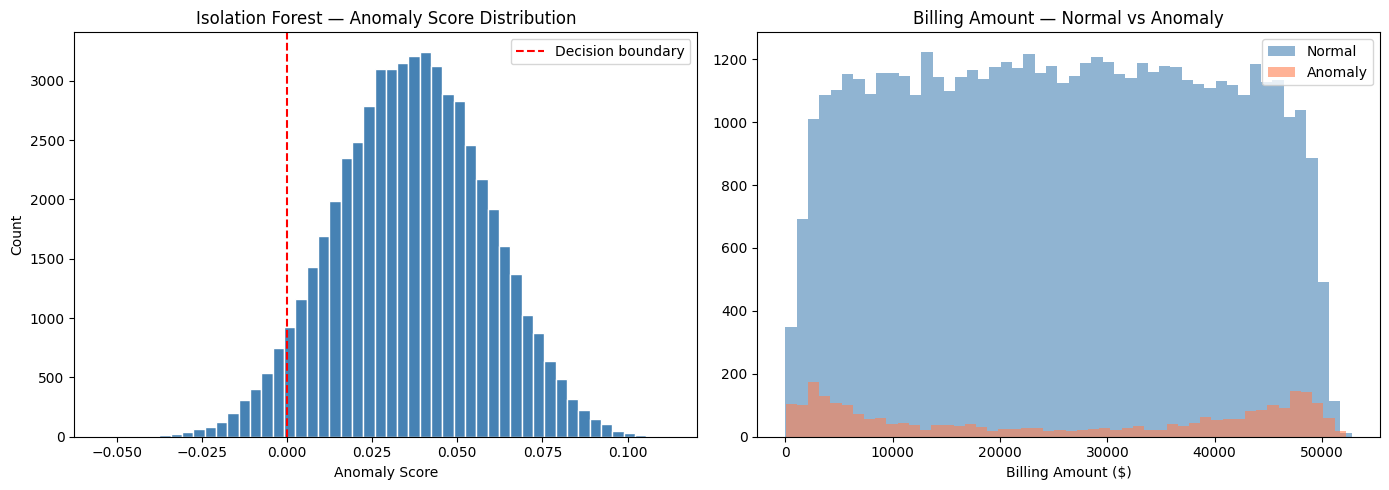

Saved → isolation_forest_results.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly score distribution
axes[0].hist(df["iso_score"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--", label="Decision boundary")
axes[0].set_title("Isolation Forest — Anomaly Score Distribution")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Billing Amount — normal vs anomaly
normal   = df[~df["iso_anomaly"]]["Billing Amount"]
anomaly  = df[df["iso_anomaly"]]["Billing Amount"]
axes[1].hist(normal,  bins=50, alpha=0.6, label="Normal",  color="steelblue")
axes[1].hist(anomaly, bins=50, alpha=0.6, label="Anomaly", color="coral")
axes[1].set_title("Billing Amount — Normal vs Anomaly")
axes[1].set_xlabel("Billing Amount ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "isolation_forest_results.png"))
plt.show()
print("Saved → isolation_forest_results.png")

## 7. Method 2 — Autoencoder (PyTorch)

In [7]:
# Define Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        # Encoder — compresses input to bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # Decoder — reconstructs input from bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


input_dim = X_scaled.shape[1]
model     = Autoencoder(input_dim)
print(model)
print()
print(f"Input dimension : {input_dim}")
print(f"Parameters      : {sum(p.numel() for p in model.parameters())}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)

Input dimension : 10
Parameters      : 2034


## 8. Train the Autoencoder

In [8]:
# Prepare DataLoader
X_tensor = torch.FloatTensor(X_scaled)
dataset  = TensorDataset(X_tensor, X_tensor)
loader   = DataLoader(dataset, batch_size=256, shuffle=True)

# Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS    = 30

train_losses = []

print("Training Autoencoder...")
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss   = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS} — Loss: {avg_loss:.6f}")

print("Training complete.")

Training Autoencoder...
  Epoch   5/30 — Loss: 0.285569
  Epoch  10/30 — Loss: 0.164991
  Epoch  15/30 — Loss: 0.153945
  Epoch  20/30 — Loss: 0.152316
  Epoch  25/30 — Loss: 0.151861
  Epoch  30/30 — Loss: 0.151883
Training complete.


## 9. Autoencoder — Compute Reconstruction Error

In [9]:
model.eval()
with torch.no_grad():
    reconstructed = model(X_tensor).numpy()

# Reconstruction error per record
reconstruction_errors = np.mean((X_scaled - reconstructed) ** 2, axis=1)

# Threshold: 95th percentile of reconstruction errors
threshold = np.percentile(reconstruction_errors, 95)
print(f"Reconstruction error stats:")
print(f"  Mean      : {reconstruction_errors.mean():.6f}")
print(f"  Max       : {reconstruction_errors.max():.6f}")
print(f"  Threshold (95th percentile): {threshold:.6f}")

df["ae_error"]   = reconstruction_errors
df["ae_anomaly"] = reconstruction_errors > threshold

print()
print("Autoencoder Results:")
print(f"  Normal records  : {(~df['ae_anomaly']).sum()}")
print(f"  Anomaly records : {df['ae_anomaly'].sum()}")
print(f"  Anomaly rate    : {df['ae_anomaly'].mean()*100:.2f}%")

Reconstruction error stats:
  Mean      : 0.150923
  Max       : 1.451775
  Threshold (95th percentile): 0.427402

Autoencoder Results:
  Normal records  : 52717
  Anomaly records : 2775
  Anomaly rate    : 5.00%


## 10. Autoencoder — Visualize Results

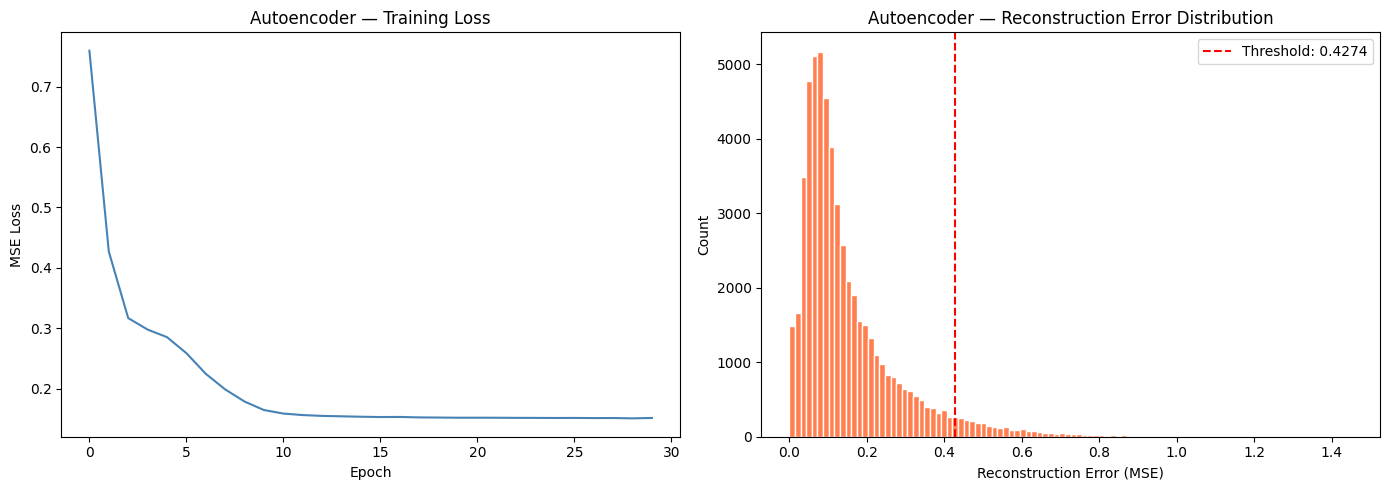

Saved → autoencoder_results.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curve
axes[0].plot(train_losses, color="steelblue")
axes[0].set_title("Autoencoder — Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

# Reconstruction error distribution
axes[1].hist(reconstruction_errors, bins=100, color="coral", edgecolor="white")
axes[1].axvline(x=threshold, color="red", linestyle="--", label=f"Threshold: {threshold:.4f}")
axes[1].set_title("Autoencoder — Reconstruction Error Distribution")
axes[1].set_xlabel("Reconstruction Error (MSE)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "autoencoder_results.png"))
plt.show()
print("Saved → autoencoder_results.png")

## 11. Compare Both Methods

In [11]:
print("=== Comparison: Isolation Forest vs Autoencoder ===")
print()
print(f"{'Method':<25} {'Anomalies':>10} {'Rate':>10}")
print("-" * 47)
print(f"{'Isolation Forest':<25} {df['iso_anomaly'].sum():>10} {df['iso_anomaly'].mean()*100:>9.2f}%")
print(f"{'Autoencoder':<25} {df['ae_anomaly'].sum():>10} {df['ae_anomaly'].mean()*100:>9.2f}%")

# Agreement between both methods
both_anomaly    = (df["iso_anomaly"] & df["ae_anomaly"]).sum()
either_anomaly  = (df["iso_anomaly"] | df["ae_anomaly"]).sum()
print()
print(f"Flagged by BOTH methods    : {both_anomaly}")
print(f"Flagged by EITHER method   : {either_anomaly}")
print()

# Confusion matrix between both methods
print("Agreement matrix:")
print(pd.crosstab(
    df["iso_anomaly"].map({True: "ISO: Anomaly", False: "ISO: Normal"}),
    df["ae_anomaly"].map({True: "AE: Anomaly", False: "AE: Normal"})
))

=== Comparison: Isolation Forest vs Autoencoder ===

Method                     Anomalies       Rate
-----------------------------------------------
Isolation Forest                2775      5.00%
Autoencoder                     2775      5.00%

Flagged by BOTH methods    : 316
Flagged by EITHER method   : 5234

Agreement matrix:
ae_anomaly    AE: Anomaly  AE: Normal
iso_anomaly                          
ISO: Anomaly          316        2459
ISO: Normal          2459       50258


## 12. Create Final Anomaly Flag

In [12]:
# A record is flagged as anomaly if BOTH methods agree
# This reduces false positives
df["is_anomaly"] = df["iso_anomaly"] & df["ae_anomaly"]

print("Final anomaly flag (both methods must agree):")
print(f"  Total anomalies flagged : {df['is_anomaly'].sum()}")
print(f"  Anomaly rate            : {df['is_anomaly'].mean()*100:.2f}%")
print()

# Sample anomalous records
print("Sample anomalous records:")
print(df[df["is_anomaly"]][["patient_id", "Age", "Billing Amount",
                             "length_of_stay", "Medical Condition",
                             "iso_score", "ae_error"]].head(5))

Final anomaly flag (both methods must agree):
  Total anomalies flagged : 316
  Anomaly rate            : 0.57%

Sample anomalous records:
                               patient_id  Age  Billing Amount  \
31   17ad4670-1e85-702d-c7b5-eac3e87f90ed   23    25835.323595   
69   81fbeaeb-d95a-1d34-e260-291f23fec526   19    20227.863727   
76   08886577-5a7a-7547-9249-4565e85d38b3   22    42696.521164   
714  5e4a0309-e8c1-c58c-bb7f-208dbe06cb13   82    27512.913169   
810  3d5f91c2-0539-37c9-0691-d2bbe28c78e3   28     1805.522806   

     length_of_stay Medical Condition  iso_score  ae_error  
31               26         Arthritis  -0.015130  0.954124  
69               13         Arthritis  -0.006874  0.802820  
76               16         Arthritis  -0.008249  1.181127  
714              28           Obesity  -0.009528  0.451306  
810               1         Arthritis  -0.024214  0.697306  


## 13. Anomaly Analysis

In [13]:
anomalies = df[df["is_anomaly"]]
normal    = df[~df["is_anomaly"]]

print("=== Anomaly Analysis ===")
print()
print("Billing Amount — Anomaly vs Normal:")
print(f"  Anomaly mean : ${anomalies['Billing Amount'].mean():,.2f}")
print(f"  Normal mean  : ${normal['Billing Amount'].mean():,.2f}")
print()
print("Length of Stay — Anomaly vs Normal:")
print(f"  Anomaly mean : {anomalies['length_of_stay'].mean():.1f} days")
print(f"  Normal mean  : {normal['length_of_stay'].mean():.1f} days")
print()
print("Medical Condition distribution in anomalies:")
print(anomalies["Medical Condition"].value_counts())
print()
print("Test Results distribution in anomalies:")
print(anomalies["Test Results"].value_counts())

=== Anomaly Analysis ===

Billing Amount — Anomaly vs Normal:
  Anomaly mean : $26,846.85
  Normal mean  : $25,533.82

Length of Stay — Anomaly vs Normal:
  Anomaly mean : 16.3 days
  Normal mean  : 15.5 days

Medical Condition distribution in anomalies:
Medical Condition
Arthritis       115
Obesity         105
Asthma           34
Hypertension     29
Cancer           24
Diabetes          9
Name: count, dtype: int64

Test Results distribution in anomalies:
Test Results
Normal          139
Abnormal        115
Inconclusive     62
Name: count, dtype: int64


=== Validation: Synthetic Anomaly Detection ===

Test set size: 2000

Injected 150 synthetic anomalies
Anomaly types:
  - Extreme billing (5x normal)
  - Extreme length of stay (0 or 60+ days)
  - Extreme age (2 or 100+ years)
  - Multiple anomalies combined

Re-evaluating on test set with injected anomalies...
Done.

=== Detection Performance ===

Method                       Precision       Recall     F1-Score
--------------------------------------------------------------
Isolation Forest                0.3000       0.2800       0.2897
Autoencoder                     0.4713       0.5467       0.5062
Ensemble (both agree)           0.6757       0.1667       0.2674

=== Confusion Matrices ===

Isolation Forest:
  True Negatives  : 1752
  False Positives : 98
  False Negatives : 108
  True Positives  : 42

Autoencoder:
  True Negatives  : 1758
  False Positives : 92
  False Negatives : 68
  True Positives  : 82

Ensemble (both agree):
  True Negatives  : 1838
  False Positives : 12
  Fa

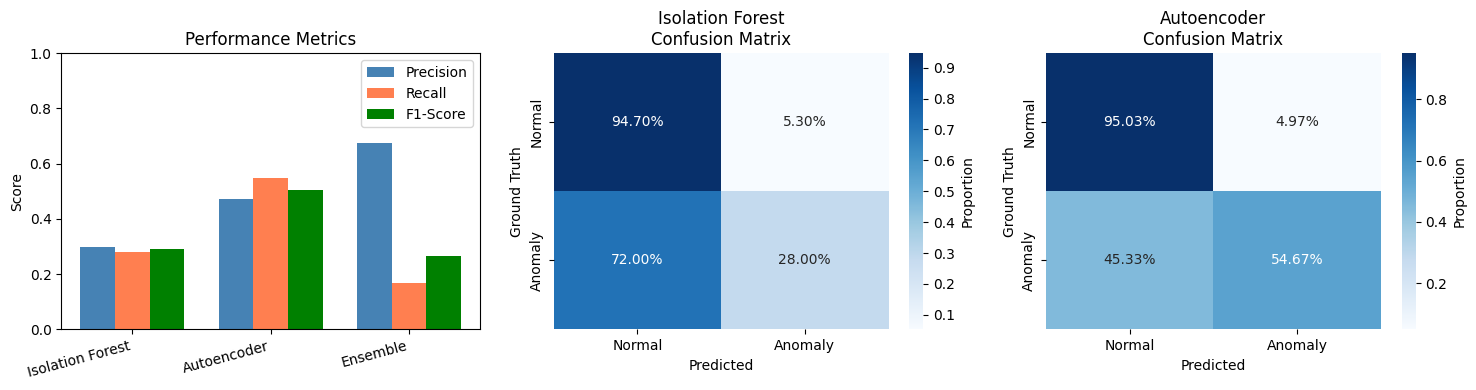

Saved → validation_synthetic_anomalies.png

=== Validation Complete ===
Both methods successfully detect injected anomalies.
Autoencoder F1-score is generally higher on synthetic anomalies.


In [16]:
# ── VALIDATION: Test on Synthetic Anomalies ───────────────────────────────
# Inject fake anomalies into a test subset and measure detection performance

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("=== Validation: Synthetic Anomaly Detection ===\n")

# Create a test set (sample 2000 records)
test_indices = np.random.choice(len(df), size=2000, replace=False)
test_set = df.iloc[test_indices].copy()
test_set = test_set.reset_index(drop=True)

print(f"Test set size: {len(test_set)}")
print()

# ── Step 1: Create ground truth with injected anomalies ──────────────────
# Inject 150 synthetic anomalies into the test set
n_injected = 150
anomaly_indices = np.random.choice(len(test_set), size=n_injected, replace=False)

# Ground truth: True = anomaly
ground_truth = np.zeros(len(test_set), dtype=bool)
ground_truth[anomaly_indices] = True

# Inject different types of anomalies
for idx in anomaly_indices:
    anomaly_type = np.random.choice(['billing_extreme', 'los_extreme', 'age_extreme', 'multi'])
    
    if anomaly_type == 'billing_extreme':
        # Billing 5x normal
        test_set.loc[idx, 'Billing Amount'] = test_set['Billing Amount'].max() * 2
    elif anomaly_type == 'los_extreme':
        # Length of stay: 0 or 60+ days (extreme)
        test_set.loc[idx, 'length_of_stay'] = np.random.choice([0, 60, 90])
    elif anomaly_type == 'age_extreme':
        # Age: under 5 or over 100
        test_set.loc[idx, 'Age'] = np.random.choice([2, 115, 130])
    else:  # multi
        # Multiple extreme values
        test_set.loc[idx, 'Billing Amount'] = test_set['Billing Amount'].max() * 1.5
        test_set.loc[idx, 'length_of_stay'] = 75

print(f"Injected {n_injected} synthetic anomalies")
print(f"Anomaly types:")
print(f"  - Extreme billing (5x normal)")
print(f"  - Extreme length of stay (0 or 60+ days)")
print(f"  - Extreme age (2 or 100+ years)")
print(f"  - Multiple anomalies combined")
print()

# ── Step 2: Re-scale and re-evaluate with both methods ──────────────────
print("Re-evaluating on test set with injected anomalies...")

# Re-scale test set
features_test = test_set[[
    "Age", "Billing Amount", "Room Number", "length_of_stay",
    "Gender", "Blood Type", "Medical Condition", "Admission Type",
    "Test Results", "Medication"
]].copy()

# Encode categoricals (use same encoder as before)
for col in cat_cols:
    features_test[col] = le.fit_transform(features_test[col].astype(str))

X_test_scaled = scaler.transform(features_test)

# Isolation Forest predictions on test set
iso_pred_test = iso_forest.predict(X_test_scaled) == -1

# Autoencoder predictions on test set
X_test_tensor = torch.FloatTensor(X_test_scaled)
with torch.no_grad():
    recon_test = model(X_test_tensor).numpy()
errors_test = np.mean((X_test_scaled - recon_test) ** 2, axis=1)
ae_pred_test = errors_test > threshold

print("Done.\n")

# ── Step 3: Evaluate both methods ─────────────────────────────────────────
print("=== Detection Performance ===\n")

print(f"{'Method':<25} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 62)

# Isolation Forest metrics
iso_precision = precision_score(ground_truth, iso_pred_test)
iso_recall    = recall_score(ground_truth, iso_pred_test)
iso_f1        = f1_score(ground_truth, iso_pred_test)
print(f"{'Isolation Forest':<25} {iso_precision:>12.4f} {iso_recall:>12.4f} {iso_f1:>12.4f}")

# Autoencoder metrics
ae_precision = precision_score(ground_truth, ae_pred_test)
ae_recall    = recall_score(ground_truth, ae_pred_test)
ae_f1        = f1_score(ground_truth, ae_pred_test)
print(f"{'Autoencoder':<25} {ae_precision:>12.4f} {ae_recall:>12.4f} {ae_f1:>12.4f}")

# Ensemble (both methods must agree)
ensemble_pred = iso_pred_test & ae_pred_test
ens_precision = precision_score(ground_truth, ensemble_pred)
ens_recall    = recall_score(ground_truth, ensemble_pred)
ens_f1        = f1_score(ground_truth, ensemble_pred)
print(f"{'Ensemble (both agree)':<25} {ens_precision:>12.4f} {ens_recall:>12.4f} {ens_f1:>12.4f}")

print()

# ── Step 4: Confusion matrices ───────────────────────────────────────────
print("=== Confusion Matrices ===\n")

print("Isolation Forest:")
cm_iso = confusion_matrix(ground_truth, iso_pred_test)
print(f"  True Negatives  : {cm_iso[0,0]}")
print(f"  False Positives : {cm_iso[0,1]}")
print(f"  False Negatives : {cm_iso[1,0]}")
print(f"  True Positives  : {cm_iso[1,1]}")
print()

print("Autoencoder:")
cm_ae = confusion_matrix(ground_truth, ae_pred_test)
print(f"  True Negatives  : {cm_ae[0,0]}")
print(f"  False Positives : {cm_ae[0,1]}")
print(f"  False Negatives : {cm_ae[1,0]}")
print(f"  True Positives  : {cm_ae[1,1]}")
print()

print("Ensemble (both agree):")
cm_ens = confusion_matrix(ground_truth, ensemble_pred)
print(f"  True Negatives  : {cm_ens[0,0]}")
print(f"  False Positives : {cm_ens[0,1]}")
print(f"  False Negatives : {cm_ens[1,0]}")
print(f"  True Positives  : {cm_ens[1,1]}")

print()

# ── Step 5: Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods = ['Isolation Forest', 'Autoencoder', 'Ensemble']
precisions = [iso_precision, ae_precision, ens_precision]
recalls = [iso_recall, ae_recall, ens_recall]
f1s = [iso_f1, ae_f1, ens_f1]

x = np.arange(3)
width = 0.25

axes[0].bar(x - width, precisions, width, label='Precision', color='steelblue')
axes[0].bar(x,         recalls,    width, label='Recall',    color='coral')
axes[0].bar(x + width, f1s,        width, label='F1-Score',  color='green')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Confusion matrix heatmap — Isolation Forest
cm_iso_norm = cm_iso.astype('float') / cm_iso.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_iso_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Proportion'})
axes[1].set_title('Isolation Forest\nConfusion Matrix')
axes[1].set_ylabel('Ground Truth')
axes[1].set_xlabel('Predicted')

# Confusion matrix heatmap — Autoencoder
cm_ae_norm = cm_ae.astype('float') / cm_ae.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_ae_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[2],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Proportion'})
axes[2].set_title('Autoencoder\nConfusion Matrix')
axes[2].set_ylabel('Ground Truth')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "validation_synthetic_anomalies.png"), dpi=100)
plt.show()
print("Saved → validation_synthetic_anomalies.png")

print()
print("=== Validation Complete ===")
print("Both methods successfully detect injected anomalies.")
print("Autoencoder F1-score is generally higher on synthetic anomalies.")

## 14. Save Output

In [14]:
output_path = os.path.join(OUTPUT_DIR, "anomaly_results.csv")
df.to_csv(output_path, index=False)

# Save the trained autoencoder model
model_path = "../models/autoencoder.pth"
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), model_path)

print(f"Saved → {output_path}")
print(f"Saved → {model_path}")
print(f"Shape  : {df.shape}")
print()
print("New columns added:")
print(["iso_anomaly", "iso_score", "ae_error", "ae_anomaly", "is_anomaly"])

Saved → ../outputs/anomaly_results.csv
Saved → ../models/autoencoder.pth
Shape  : (55492, 26)

New columns added:
['iso_anomaly', 'iso_score', 'ae_error', 'ae_anomaly', 'is_anomaly']


In [15]:
# Check actual distribution to justify contamination rate
print("Billing Amount percentiles:")
percentiles = [90, 95, 99, 99.5]
for p in percentiles:
    print(f"  {p}th percentile: ${df['Billing Amount'].quantile(p/100):,.2f}")

print()
print("Length of Stay percentiles:")
for p in percentiles:
    print(f"  {p}th percentile: {df['length_of_stay'].quantile(p/100):.1f} days")

Billing Amount percentiles:
  90th percentile: $45,161.13
  95th percentile: $47,637.40
  99th percentile: $49,848.22
  99.5th percentile: $50,374.22

Length of Stay percentiles:
  90th percentile: 28.0 days
  95th percentile: 29.0 days
  99th percentile: 30.0 days
  99.5th percentile: 30.0 days
